# Rotatable bonds vs. conformer-ensemble variance

This notebook computes, for each molecule in an ensemble JSONL file, the variance of its conformer ensemble (based on relative MMFF energies carried in the ensemble) and correlates it with the molecule's rotatable-bond count. A scatter plot visualizes the relationship.

Notes:
- The ensemble JSONL is produced by `run_batch.py ... --tier tier1` (or `--tier xtb`).
- Each molecule entry contains conformers with relative energies `energy_kcal_mol` and Boltzmann weights `weight`. We compute the Boltzmann-weighted variance of the relative energies as a simple measure of ensemble spread.
- If a molecule has a single conformer, variance is 0.


In [1]:
# Configuration — change the path if needed
ensemble_path = '/home/alex/freesolv_gpr/data/structures/ensembles_tier1.jsonl'  # or 'ensembles_xtb.jsonl' if available
# Plot kind: 'scatter' (default) or 'box' for grouped boxplots by rotatable-bond count
plot_kind = 'scatter'  # options: 'scatter', 'box'
# Only show test split?
only_test_split = True
# Output path for the table
output_table_path = '/home/alex/freesolv_gpr/data/energy_spread_vs_rotatable_bonds.csv'
# Run GPR pipeline to get predictive variances?
run_gpr = True
# GPR configuration overrides
gpr_overrides = ['training.mode=uncertain']


In [2]:
import json
import math
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add src to path if needed for imports
sys.path.append('/home/alex/freesolv_gpr')
from src.gpr_uncertain import (
    split_train_test_by_fraction,
    load_descriptors_npz,
    load_freesolv_labels,
    train_gpr_uncertain,
    predict_gpr_uncertain,
    train_gpr_deterministic,
    predict_gpr_deterministic
)
from src.preprocess import VarianceFloor, DistributionalInputStandardizer
from hydra import initialize, compose, core


In [3]:
# Load ensembles (JSON Lines)
records = []
path = Path(ensemble_path)
assert path.exists(), f'Ensemble file not found: {path}'
with path.open() as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            rec = json.loads(line)
            records.append(rec)
        except json.JSONDecodeError:
            # Some files may contain a single big JSON array; attempt to parse once
            f.seek(0)
            data = json.load(f)
            if isinstance(data, list):
                records = data
            else:
                raise
            break
len(records)


642

In [4]:
def weighted_mean(x, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    if x.size == 0:
        return np.nan
    if w.size != x.size:
        raise ValueError('weights and values must be same length')
    s = w.sum()
    if s == 0:
        return float(np.nan)
    return float((w * x).sum() / s)


def weighted_var(x, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    if x.size <= 1:
        return 0.0
    m = weighted_mean(x, w)
    s = w.sum()
    if s == 0:
        return float(np.nan)
    # population-style weighted variance
    return float((w * (x - m) ** 2).sum() / s)


In [5]:
rows = []
for rec in records:
    nrot = rec.get('n_rotatable_bonds')
    smiles = rec.get('smiles')
    confs = rec.get('conformers', [])
    energies = [c.get('energy_kcal_mol', np.nan) for c in confs]
    weights = [c.get('weight', np.nan) for c in confs]
    # Filter out conformers missing energy or weight
    #good = [i for i, (e, w) in enumerate(zip(energies, weights)) if np.isfinite(e) and np.isfinite(w)]
    #energies = [energies[i] for i in good]
    #weights = [weights[i] for i in good]
    wvar = weighted_var(energies, weights)
    rows.append({
        'smiles': smiles,
        'n_rotatable_bonds': nrot,
        'n_final': rec.get('n_final', len(confs)),
        'energy_var_kcal2': wvar,
        'energy_std_kcal': math.sqrt(wvar) if np.isfinite(wvar) else np.nan,
        'id': rec.get('id'),
    })

df = pd.DataFrame(rows)
df.head()


,smiles,n_rotatable_bonds,n_final,energy_var_kcal2,energy_std_kcal,id
0,CS(=O)(=O)Cl,0,1,0.000000e+00,0.000000e+00,1
1,CCc1cnccn1,1,2,1.364010e-18,1.167908e-09,3
2,CC(C)C=C,1,1,0.000000e+00,0.000000e+00,2
3,C(Br)Br,0,1,0.000000e+00,0.000000e+00,10
4,CN(C)C(=O)c1ccc(cc1)OC,2,4,2.132847e-02,1.460427e-01,0


In [6]:
# Filter for test split if requested
if only_test_split:
    # We need to know the total number of samples to replicate the split
    # In GPR pipeline, N is the number of samples in the descriptors NPZ.
    # Here we assume the ensemble JSONL covers the same set or a superset.
    # To be exactly consistent, we should use the same N and seed.
    # The GPR pipeline uses N = len(ids) where ids are from descriptors_tier1.npz.
    # For FreeSolv, N is usually 642.
    
    # Load all IDs available in FreeSolv to ensure consistent indexing
    # or just use the max ID from our records as an estimate for N.
    max_id = df['id'].max()
    N = max_id + 1 # Assuming IDs are 0-indexed or 1-indexed and max_id covers it
    
    # Actually, the GPR pipeline uses len(ids) from the npz.
    # Let's try to load the NPZ to get the exact N and ids used there.
    npz_path = '/home/alex/freesolv_gpr/data/reps/soap/descriptors_tier1.npz'
    if Path(npz_path).exists():
        data_npz = np.load(npz_path)
        ids_in_gpr = data_npz['ids'].astype(int)
        N_gpr = len(ids_in_gpr)
        tr_idx, te_idx = split_train_test_by_fraction(N_gpr, train_frac=0.8, seed=0)
        test_ids = set(ids_in_gpr[te_idx])
        df = df[df['id'].isin(test_ids)].copy()
        print(f"Filtered to test split: {len(df)} molecules")
        
        if run_gpr:
            print("Running GPR pipeline...")
            import torch
            core.global_hydra.GlobalHydra.instance().clear()
            with initialize(config_path="../conf", version_base="1.1"):
                cfg = compose(config_name="config", overrides=gpr_overrides)
            
            mu = data_npz["mu"]
            sigma = data_npz["sigma"]
            var = sigma**2
            y_all = load_freesolv_labels(cfg.data.label_path)
            y = y_all[ids_in_gpr]
            
            mu_tr, var_tr, y_tr = mu[tr_idx], var[tr_idx], y[tr_idx]
            mu_te, var_te, y_te = mu[te_idx], var[te_idx], y[te_idx]
            
            device = "cuda" if torch.cuda.is_available() else "cpu"
            dtype = torch.float32
            
            floor = VarianceFloor(percentile=cfg.training.variance_floor_percentile)
            
            if cfg.training.mode == "uncertain":
                mu_tr_t = torch.as_tensor(mu_tr, dtype=dtype, device=device)
                var_tr_t = floor.fit_transform(torch.as_tensor(var_tr, dtype=dtype, device=device))
                mu_te_t = torch.as_tensor(mu_te, dtype=dtype, device=device)
                var_te_t = floor.transform(torch.as_tensor(var_te, dtype=dtype, device=device))
                
                standardizer = DistributionalInputStandardizer().fit(mu_tr_t, var_tr_t, var_floor_value=floor.eps_)
                mu_tr_t, var_tr_t = standardizer.transform(mu_tr_t, var_tr_t)
                mu_te_t, var_te_t = standardizer.transform(mu_te_t, var_te_t)
                
                model, likelihood = train_gpr_uncertain(mu_tr_t, var_tr_t, y_tr, cfg)
                _, pred_var = predict_gpr_uncertain(model, likelihood, mu_te_t, var_te_t)
            else:
                model, likelihood = train_gpr_deterministic(mu_tr, y_tr, cfg)
                _, pred_var = predict_gpr_deterministic(model, likelihood, mu_te)
            
            # Map predictive variances back to df
            # te_idx are the relative indices into ids_in_gpr
            # ids_in_gpr[te_idx] are the absolute molecule IDs
            id_to_pred_var = dict(zip(ids_in_gpr[te_idx], pred_var))
            df['predictive_var'] = df['id'].map(id_to_pred_var)
            print("GPR predictive variances added to table.")
            
    else:
        print(f"Warning: {npz_path} not found. Cannot accurately filter for test split.")

df.head()


Filtered to test split: 128 molecules
Running GPR pipeline...


/tmp/ipykernel_937221/1594153817.py:31: Hydra14MigrationWarning: 
version_base="1.1" selects Hydra 1.1 compatibility behavior.
Hydra 1.4 will remove this compatibility behavior.
Before upgrading to Hydra 1.4, set version_base="1.3" and test your application.
See https://hydra.cc/docs/upgrades/1.3_to_1.4/prepare_for_1_4/ for preparation instructions.
  with initialize(config_path="../conf", version_base="1.1"):


[VarianceFloor.fit] 52724/56540 entries (93.3%) exactly zero in training data
[VarianceFloor.fit] nonzero variance range: [1.391e-20, 2.567e-02]
[VarianceFloor.fit] eps = 1.103e-10 (10.0th percentile of nonzero variances)
[VarianceFloor.fit] log(eps)=-22.93 vs. log(median nonzero)=-13.89 (gap: 9.04 -- if this is large, e.g. >6-8, consider a higher percentile so the floor isn't an extreme outlier)
[info] DistributionalInputStandardizer: 34/110 dimensions had < 3 informative (non-floored) values; using the median scale of the other dimensions for them.
var-term range: 33.48358917236328 229.80067443847656
mean-term range: -100.97418212890625 1964.6390380859375
[train] epoch 1/200  loss=2.3924
[train] epoch 21/200  loss=2.1308
[train] epoch 41/200  loss=2.1260
[train] epoch 61/200  loss=2.1230
[train] epoch 81/200  loss=2.1228
[train] epoch 101/200  loss=2.1228
[train] epoch 121/200  loss=2.1228
[train] epoch 141/200  loss=2.1228
[train] epoch 161/200  loss=2.1228
[train] epoch 181/200  lo

,smiles,n_rotatable_bonds,n_final,energy_var_kcal2,energy_std_kcal,id,predictive_var
1,CCc1cnccn1,1,2,1.364010e-18,1.167908e-09,3,2.154477
3,C(Br)Br,0,1,0.000000e+00,0.000000e+00,10,3.762719
7,c1cc(ccc1O)Br,0,1,0.000000e+00,0.000000e+00,18,3.226426
11,COC(=O)C1CC1,1,3,1.678874e-02,1.295714e-01,23,2.144273
16,CC(C)(C)O,0,1,0.000000e+00,0.000000e+00,26,2.037358


In [7]:
# Save to table
cols_to_save = ['smiles', 'n_rotatable_bonds', 'energy_std_kcal']
if 'predictive_var' in df.columns:
    cols_to_save.append('predictive_var')
df_to_save = df[cols_to_save].copy()
df_to_save.rename(columns={'energy_std_kcal': 'energy_spread'}, inplace=True)
df_to_save.to_csv(output_table_path, index=False)
print(f"Saved table to {output_table_path}")
display(df.head())


Saved table to /home/alex/freesolv_gpr/data/energy_spread_vs_rotatable_bonds.csv


,smiles,n_rotatable_bonds,n_final,energy_var_kcal2,energy_std_kcal,id,predictive_var
1,CCc1cnccn1,1,2,1.364010e-18,1.167908e-09,3,2.154477
3,C(Br)Br,0,1,0.000000e+00,0.000000e+00,10,3.762719
7,c1cc(ccc1O)Br,0,1,0.000000e+00,0.000000e+00,18,3.226426
11,COC(=O)C1CC1,1,3,1.678874e-02,1.295714e-01,23,2.144273
16,CC(C)(C)O,0,1,0.000000e+00,0.000000e+00,26,2.037358


In [8]:
# Drop rows with missing values and compute correlation
clean = df.dropna(subset=['n_rotatable_bonds', 'energy_std_kcal'])
x = clean['n_rotatable_bonds'].to_numpy(dtype=float)
y = clean['energy_std_kcal'].to_numpy(dtype=float)
if x.size > 1 and np.std(x) > 0 and np.std(y) > 0:
    r = np.corrcoef(x, y)[0, 1]
else:
    r = np.nan
print(f'Pearson r (rotatable bonds vs energy std): {r:.3f}')
len(clean)


Pearson r (rotatable bonds vs energy std): 0.774


128

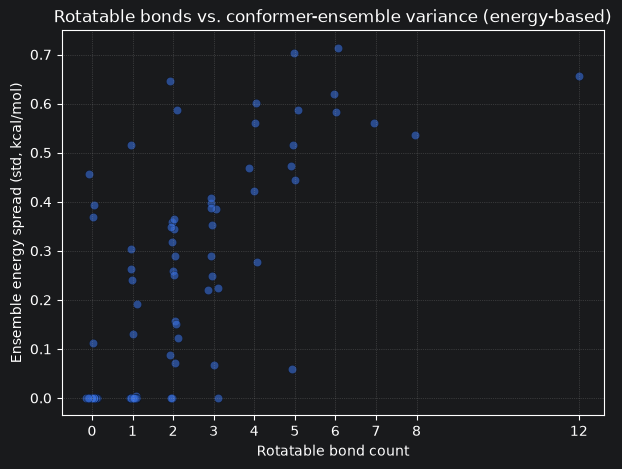

In [9]:
# Plot: scatter (default) or boxplot by rotatable-bond count
plt.figure(figsize=(7, 5))
if plot_kind == 'box':
    # Group energy std values by rotatable-bond count
    counts = sorted(pd.unique(clean['n_rotatable_bonds']))
    data_by_count = [clean.loc[clean['n_rotatable_bonds'] == c, 'energy_std_kcal'].to_numpy(dtype=float) for c in counts]
    bp = plt.boxplot(
        data_by_count,
        positions=counts,
        widths=0.6,
        patch_artist=True,
        showfliers=True,
        medianprops=dict(color='black', linewidth=1.2),
        boxprops=dict(facecolor='#a6cee3', edgecolor='#1f78b4'),
        whiskerprops=dict(color='#1f78b4'),
        capprops=dict(color='#1f78b4')
    )
    plt.xticks(counts)
    plt.title('Ensemble energy spread vs rotatable bonds (boxplot per count)')
else:
    # Scatter plot with slight jitter on x for visibility
    rng = np.random.default_rng(0)
    x_jitter = x + rng.normal(0, 0.06, size=x.shape)
    plt.scatter(x_jitter, y, alpha=0.6, edgecolor='k', linewidths=0.3)
    if x.size:
        plt.xticks(sorted(pd.unique(clean['n_rotatable_bonds'])))
    plt.title('Rotatable bonds vs. conformer-ensemble variance (energy-based)')

plt.xlabel('Rotatable bond count')
plt.ylabel('Ensemble energy spread (std, kcal/mol)')
plt.grid(True, linestyle=':', alpha=0.4)
plt.show()


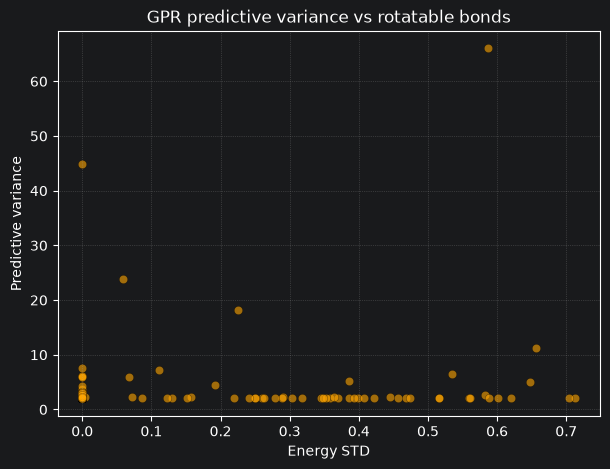

In [10]:
# Plot: Predictive variance vs. rotatable bonds (if available)
if 'predictive_var' in df.columns:
    plt.figure(figsize=(7, 5))
    clean_pv = df.dropna(subset=['energy_std_kcal', 'predictive_var'])
    x_pv = clean_pv['energy_std_kcal'].to_numpy(dtype=float)
    y_pv = clean_pv['predictive_var'].to_numpy(dtype=float)
    
    if plot_kind == 'box':
        counts_pv = sorted(pd.unique(clean_pv['energy_std_kcal']))
        data_pv = [clean_pv.loc[clean_pv['energy_std_kcal'] == c, 'predictive_var'].to_numpy(dtype=float) for c in counts_pv]
        plt.boxplot(
            data_pv,
            positions=counts_pv,
            widths=0.6,
            patch_artist=True,
            showfliers=True,
            medianprops=dict(color='black', linewidth=1.2),
            boxprops=dict(facecolor='#fdb462', edgecolor='#eb811b'),
            whiskerprops=dict(color='#eb811b'),
            capprops=dict(color='#eb811b')
        )
        plt.xticks(counts_pv)
        plt.title('GPR predictive variance vs rotatable bonds')
    else:
        rng = np.random.default_rng(0)

        x_jitter_pv = x_pv + rng.normal(0, 0.06, size=x_pv.shape)
        plt.scatter(x_pv, y_pv, alpha=0.6, color='orange', edgecolor='k', linewidths=0.3)
        #plt.xticks(sorted(pd.unique(clean_pv['energy_std_kcal'])))
        plt.title('GPR predictive variance vs rotatable bonds')
        
    plt.xlabel('Energy STD')
    plt.ylabel('Predictive variance')
    plt.grid(True, linestyle=':', alpha=0.4)
    plt.show()
